# Don't Look 🙈
### Does checking your portfolio less really keep you invested, and what does checking cost?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

A famous explanation of why stocks pay so much more than bonds is a story about *feelings*.
Losses hurt about twice as much as gains please, and the more often you look, the more often
you see a loss. Benartzi and Thaler worked out that someone who looks once a year would be
exactly on the fence between stocks and bonds. We checked that number on ninety-two years of
data, and then asked the practical question: what does looking too often actually *cost*?

> 📓 **This is the plain-language layer.** The prospect-theory machinery, the bootstrap and
> every robustness sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it, on the
> real (frozen, fingerprinted) tapes.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore", category=RuntimeWarning)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 80
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from dontlook import data, strategy as st

m = data.load_monthly()
X = m[["stock", "bond", "bill"]]
HAVE_DAILY = data.have_daily()
d = data.load_daily() if HAVE_DAILY else None
H = st.HORIZONS_M
print(f"as-of {data.AS_OF} | monthly {X.index[0]:%Y-%m} -> {X.index[-1]:%Y-%m} "
      f"({len(X)} months, fingerprint {data.fingerprint(m)})")
if HAVE_DAILY:
    print(f"daily S&P 500 PRICE index {d.index[0]:%Y-%m-%d} -> {d.index[-1]:%Y-%m-%d} "
          f"({len(d)} sessions, fingerprint {data.fingerprint(d)})")
C = {"stock": "#c0392b", "bond": "#1f6feb", "bill": "#8b949e"}

as-of 2018-11-30 | monthly 1926-07 -> 2018-11 (1109 months, fingerprint b5226282e9da)
daily S&P 500 PRICE index 1990-01-03 -> 2018-11-30 (7287 sessions, fingerprint f8b91faaa94b)


## Beat 0 · Verdict (real tape)

*Numbers from the pinned run in [`docs/results.md`](../docs/results.md), as-of 2018-11-30.*

| Question | Answer |
|---|---|
| Do you see fewer losses if you look less often? | Yes, from 47% of days to 25% of years and 5% of decades. |
| Does a loss-averse investor switch from bonds to stocks as they look less? | Yes, and the switch is statistically real. |
| At about one year, as the famous paper says? | The data say 30 months (2.5 years), somewhere between 2.6 months to 9.4 years. One year is what you get if you pretend months are independent (11.6 months). |
| Does looking too often cost money? | Only if you *act* on daily or weekly moves: about 11.5% a year for a daily panicker. A yearly one loses about 1.1%, which is not distinguishable from zero. |

## 1 · The claim

> *"The equity premium is the price of looking too often."*

Shlomo Benartzi and Richard Thaler (1995) put two facts about people together:

1. **Loss aversion.** Losing \$100 hurts roughly as much as winning \$225 pleases (Tversky &
   Kahneman 1992).
2. **Myopia.** People keep score often, and every check is a fresh chance to feel a loss.

Stocks rise on average, but on any single day they are almost a coin flip. Look daily and you
spend half your life in pain. Look once a decade and you almost never see red. With the
Tversky-Kahneman numbers, they found an investor would be *indifferent* between stocks and
bonds if they looked about **once a year**. Experiments backed it up: people given less
frequent feedback took more risk (Thaler, Tversky, Kahneman & Schwartz 1997; Gneezy &
Potters 1997). The folk version is advice you have probably heard: *check your portfolio less
and you'll stay invested.*

## 2 · So what?

If it's true, two big things follow:

- **One of finance's great puzzles becomes psychology.** Stocks have beaten bonds by several
  percent a year for a century, far more than standard risk models can justify. On this account
  investors demand that premium because they *watch too much*.
- **A free improvement for savers.** If looking less makes people hold more stocks, then the
  app notification is costing them money, and *not looking* is worth real return.

Both deserve checking against the data.

## 3 · How we'd know

We fixed the tests **before** running them on the real data:

- **Is the flip real?** A loss-averse investor must clearly prefer bonds at a one-month look
  and stocks at a ten-year look. "Clearly" means under 5% odds of a fluke, measured by
  reshuffling history in two-year blocks.
- **Is it about a year?** The range of plausible break-even horizons must sit between 3 and 36
  months and include 12. If the flip is real but the range is wider, the stamp is **Weak**.
- **Does looking cost money?** We simulate an investor who goes to cash after seeing a loss and
  comes back after a gain, with realistic trading costs and no peeking ahead, and compare them
  with someone who just holds. If no checking frequency loses money with confidence, the advice
  is a **Mirage**.

## 4 · The teardown

### 4.1 How often do you *see* red?

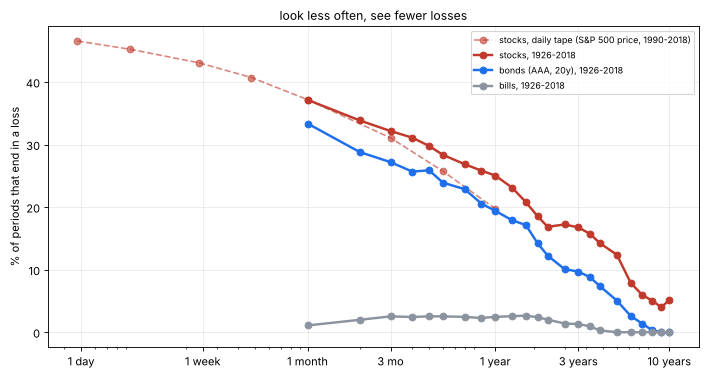

     stock   bond   bill
h                       
1   0.3720 0.3340 0.0110
12  0.2500 0.1940 0.0250
60  0.1240 0.0500 0.0000
120 0.0520 0.0000 0.0000


In [2]:
L = st.loss_probability_curve(X, H)
fig, ax = plt.subplots(figsize=(10.5, 5.2))
if HAVE_DAILY:
    Ld = st.loss_probability_curve(d[["stock"]], st.HORIZONS_D)
    ax.plot(np.array(st.HORIZONS_D) / 21.0, Ld["stock"] * 100, "o--", color=C["stock"],
            alpha=0.6, label="stocks, daily tape (S&P 500 price, 1990-2018)")
for c, lbl in (("stock", "stocks"), ("bond", "bonds (AAA, 20y)"), ("bill", "bills")):
    ax.plot(L.index, L[c] * 100, "o-", lw=2.2, color=C[c], label=lbl + ", 1926-2018")
ax.set_xscale("log")
ax.set_xticks([0.05, 0.25, 1, 3, 12, 36, 120])
ax.set_xticklabels(["1 day", "1 week", "1 month", "3 mo", "1 year", "3 years", "10 years"])
ax.set_ylabel("% of periods that end in a loss")
ax.set_title("look less often, see fewer losses", fontsize=11)
ax.legend(fontsize=8); plt.show()
print(L.loc[[1, 12, 60, 120]].round(3).to_string())

This part of the story is simply true. Check daily and stocks are down on about 47% of
days. Check yearly and it's 25%. Check once a decade and it's 5%. It is also
**mechanical**: anything that drifts up a little while jiggling a lot looks like that.

### 4.2 How does a loss-averse investor *feel* about each asset?

We score every holding period the way prospect theory does: gains count, losses count
**2.25 times**, and rare extreme outcomes get extra weight. A positive score means the investor
likes the asset over that horizon.

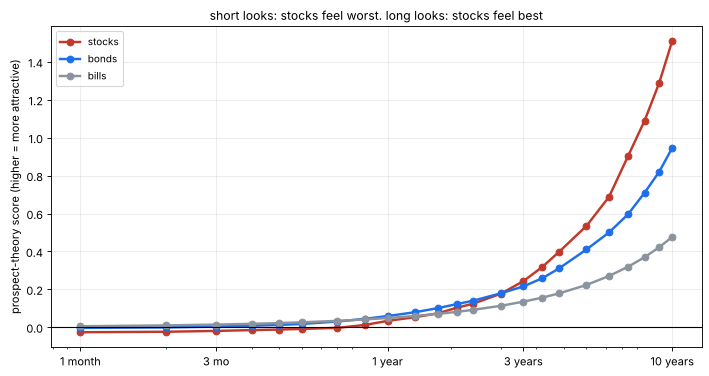

stocks beat bonds for this investor from about 30 months on


In [3]:
P = st.pt_curve(X, H)
fig, ax = plt.subplots(figsize=(10.5, 5.2))
for c, lbl in (("stock", "stocks"), ("bond", "bonds"), ("bill", "bills")):
    ax.plot(P.index, P[c], "o-", lw=2.2, color=C[c], label=lbl)
ax.axhline(0, color="k", lw=1)
ax.set_xscale("log"); ax.set_xticks([1, 3, 12, 36, 120])
ax.set_xticklabels(["1 month", "3 mo", "1 year", "3 years", "10 years"])
ax.set_ylabel("prospect-theory score (higher = more attractive)")
ax.set_title("short looks: stocks feel worst. long looks: stocks feel best", fontsize=11)
ax.legend(fontsize=9); plt.show()
gap = (P["stock"] - P["bond"]).to_numpy()
print(f"stocks beat bonds for this investor from about {st.break_even(H, gap):.0f} months on")

The crossing point is the "equilibrium" horizon. Benartzi and Thaler put it at about a year. On
the full 1926-2018 record we get **30 months (2.5 years)**.

### 4.3 How sure can we be about that crossing point?

Ninety-two years sounds like a lot, but they contain only nine separate decades. We replay
history many times, reshuffled in two-year chunks, and recompute the crossing each time.

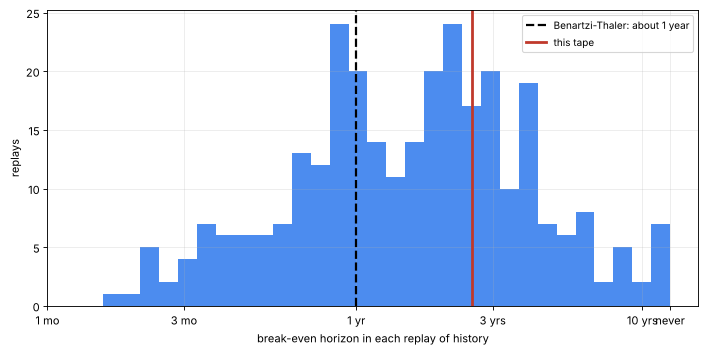

95% range: 2.6 to 118.8 months


In [4]:
boot = st.bootstrap_curves(X, H, n_boot=300, seed=1025)
s = st.summarise_gap(P, boot, "stock", "bond")
draws = np.where(np.isfinite(s["be_draws"]), s["be_draws"], 150)
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.hist(np.log10(draws), bins=30, color="#1f6feb", alpha=0.8)
ax.axvline(np.log10(12), color="k", ls="--", lw=2, label="Benartzi-Thaler: about 1 year")
ax.axvline(np.log10(s["break_even"]), color=C["stock"], lw=2.5, label="this tape")
ax.set_xticks(np.log10([1, 3, 12, 36, 120, 150]))
ax.set_xticklabels(["1 mo", "3 mo", "1 yr", "3 yrs", "10 yrs", "never"])
ax.set_xlabel("break-even horizon in each replay of history")
ax.set_ylabel("replays"); ax.legend(fontsize=9); plt.show()
print(f"95% range: {s['be_lo']:.1f} to {s['be_hi']:.1f} months")

The replays scatter from a few months to nearly a decade. The data **can't tell one year apart
from three**, so the famous "about one year" can't be confirmed on this record.

> 🔬 **For the quants.** Circular block bootstrap of the joint monthly (stock, bond, bill)
> vector, 24-month blocks. Percentile intervals and two-sided p-values. The flip itself *is*
> significant: p < 0.001 at one month, p 0.044 at ten years.

### 4.4 Where "one year" comes from

Shuffle the months **independently**, as if each month knew nothing about the last, and the
crossing lands at **11.6 months**, right on Benartzi and Thaler's number. Real markets have runs,
though. A bad year is often followed by another (1929-32 is the extreme case). That makes one-
and two-year looks scarier than independent months would suggest, and it pushes the crossing out.

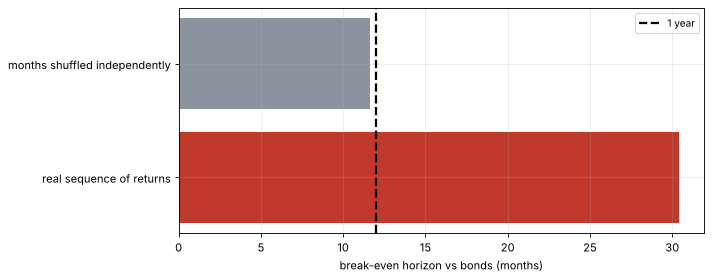

real sequence of returns          30.4 months
months shuffled independently     11.6 months


In [5]:
rows = []
for meth, lbl in (("overlapping", "real sequence of returns"),
                  ("iid", "months shuffled independently")):
    Pm = st.pt_curve(X, H, method=meth)
    rows.append((lbl, st.break_even(H, (Pm["stock"] - Pm["bond"]).to_numpy())))
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh([r[0] for r in rows], [r[1] for r in rows], color=[C["stock"], "#8b949e"])
ax.axvline(12, color="k", ls="--", lw=2, label="1 year")
ax.set_xlabel("break-even horizon vs bonds (months)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
for lbl, v in rows:
    print(f"{lbl:32s} {v:5.1f} months")

### 4.5 What does *acting* on what you see cost?

Looking itself is free. The cost comes from **reacting**. Our panicky investor checks at a fixed
rhythm. After a loss they move to cash for the next period, and after a gain they move back into
stocks. They pay 0.05% each time they switch, and they can only act on what they have already
seen.

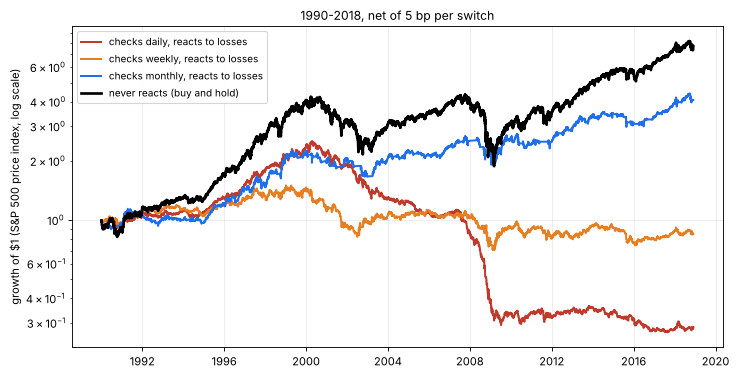

1926-2018, total return — annual return given up by the reacting investor:
      d_cagr_net  t_hac  p_ret  time_invested
freq                                         
M         0.0090 1.2660 0.1730         0.6280
Q         0.0120 1.3150 0.1800         0.6830
Y         0.0110 1.3260 0.1800         0.7620


In [6]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
if HAVE_DAILY:
    for f, col in (("D", "#c0392b"), ("W", "#e67e22"), ("M", "#1f6feb")):
        sw = st.myopic_switcher(d["stock"], d["bill"], f, cost_bps=5.0)
        ax.plot(sw.index, np.cumprod(1 + sw["net"]), lw=1.8, color=col,
                label=f"checks {st.FREQ_LABEL[f]}, reacts to losses")
    ax.plot(sw.index, np.cumprod(1 + sw["bh"]), color="k", lw=2.4,
            label="never reacts (buy and hold)")
    ax.set_yscale("log"); ax.set_ylabel("growth of $1 (S&P 500 price index, log scale)")
    ax.legend(fontsize=9); ax.set_title("1990-2018, net of 5 bp per switch", fontsize=11)
    plt.show()
t = st.discipline_table(X, ["M", "Q", "Y"], 12, cost_bps=5.0, n_boot=300)
print("1926-2018, total return — annual return given up by the reacting investor:")
print(t[["d_cagr_net", "t_hac", "p_ret", "time_invested"]].round(3).to_string())

The daily reactor is a disaster. They switch over a hundred times a year and give up about
**11.5% a year**. The weekly one gives up about 7.8%. Once the rhythm is monthly or
slower, the damage shrinks to about **1% a year**, and over ninety years that is not
distinguishable from luck (p 0.16-0.21). The slow reactor also spends less time in stocks and
carries less risk, so per unit of risk it does no worse.

## 5 · The verdict

**Signal: Weak.** The horizon really does flip a loss-averse investor's preference, and the flip clears the bar — only just, at ten years: with Tversky-Kahneman (1992) preferences a one-month evaluator prefers bonds to stocks (prospect-theory gap -0.0228, block-bootstrap p 0.000) and a ten-year evaluator prefers stocks (gap +0.564, p 0.044). The chance of *seeing* a loss on stocks falls from 47% of days to 37% of months, 25% of years and 5% of decades. The break-even horizon against bonds on 1926-2018 is **30 months (2.5 years)**, against Benartzi and Thaler's roughly one year, with a 95% block-bootstrap interval of 2.6 months to 113 months (9.4 years). That interval is far too wide to certify the one-year calibration — and the one-year figure itself turns out to be the *i.i.d.* answer: drawing the same months independently gives 11.6 months, while the real sequence of returns (overlapping windows) gives 30 months (2.5 years), and 23 months (1.9 years) on Benartzi and Thaler's own 1926-1990 window. Against bills the break-even is 17 months (1.4 years) (95% CI 4.2 months to 46 months (3.8 years)). Pre-1970 it is 11.2 months, post-1970 43 months (3.6 years); in real terms (core CPI, 1957+) 16 months (1.3 years). The loss aversion that would make an annual evaluator exactly indifferent is λ = 1.79 (Tversky-Kahneman: 2.25).

**Tradability: Fragile.** Looking less changes what you see, not what you earn, so the only money in the advice is the cost of the behaviour it prevents. The myopic investor here flees to bills after seeing a loss and returns after a gain — one lag, 5 bp one-way. The behaviour is measurably costly, net, only at the daily and weekly clocks. Daily checking gives up 11.54% a year of compound return (HAC t 5.81, 129 switches a year), while monthly checking gives up 0.88% (HAC t 1.27). Risk-adjusted, the switcher's excess Sharpe is at least as high as buy-and-hold's at the monthly, quarterly and yearly clocks — what the slow checker gives up is mostly premium it had stopped carrying risk for. So 'don't look' is a seatbelt against one specific, expensive habit — reacting to daily and weekly noise — not an edge: it earns the equity premium you were always paid for, and nothing on top.

> **In one sentence:** A loss-averse investor does come to prefer stocks once they look rarely enough, but the break-even is 30 months (2.5 years) with a 95% interval of 2.6 months to 113 months (9.4 years) — the famous one year is the i.i.d. answer — and looking less is a seatbelt, not an edge: it only pays against daily and weekly checking.

## 6 · Could you trade it?

There's nothing to trade here, only a habit to avoid.

- **"Don't look" earns the equity premium, nothing more.** Buy-and-hold collects the
  premium stocks have always paid. Not looking keeps you from throwing part of it away, and it
  adds no edge on top.
- **The habit worth breaking is reacting to short-term noise.** Selling after a red day or a red
  week is where the measured damage is, about 11.5% and 7.8% a year in this sample.
- **A yearly glance is cheap.** If you rebalance or react once a year, the cost on this record
  is about 1.1% a year and statistically indistinguishable from zero.

## 7 · Going further 🚪

- **A better bond leg.** Our bond is built from a corporate yield. A true Treasury total-return
  series would be the cleaner Benartzi-Thaler comparison.
- **Other countries.** The US had an unusually good century for stocks. A loss-averse investor
  elsewhere may never have found stocks attractive at any horizon.
- **Other reactions.** Selling half instead of everything, or a one-period time-out, would cost
  a different amount. The rule here was fixed in advance on purpose, so a fork that tries
  others should correct for trying many.
- **The quant notebook** has the λ × α sweep, the pre/post-1970 split and the real-terms check.
  The break-even moves a lot with all of them, which is the point.